# Logistic Regression Analysis: Book Adaptation Success

This notebook uses logistic regression to predict whether a movie adaptation will be "successful" based on various features.

In [2]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score, accuracy_score
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Load data
df = pd.read_csv('final_data.csv')
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (3265, 13)


,Unnamed: 0,movie_title,movie_budget,movie_revenue,movie_release,imdb_total_votes,Publisher,Pages,RatingDistTotal,Authors,Book Rating,Movie Rating,movie_profit
0,0,Jumanji,1.400925e+08,5.663988e+08,1995.0,404354.0,Scholastic,48.0,28,A.L. Singer,0.814,0.71,4.263063e+08
1,1,Heat,1.293161e+08,4.039768e+08,1995.0,779065.0,Philomel Books,220.0,19350,Mike Lupica,0.796,0.83,2.746606e+08
2,2,Heat,1.293161e+08,4.039768e+08,1995.0,779065.0,iUniverse,256.0,73,Arthur Herzog III,0.690,0.83,2.746606e+08
3,3,Sense and Sensibility,3.556194e+07,2.909613e+08,1995.0,134114.0,"Oxford University Press, USA",446.0,917623,Jane Austen,0.814,0.77,2.553994e+08
4,4,Sense and Sensibility,3.556194e+07,2.909613e+08,1995.0,134114.0,AudioGO,NaN,917839,Jane Austen,0.814,0.77,2.553994e+08


## 1. Define Target Variable: Movie Success

We'll define a movie as "successful" if it meets one of these criteria:
- **High Movie Rating**: Movie Rating >= 0.7 (top-performing adaptations)
- **Profitable**: Movie profit > 0 (financially successful)

This creates a binary classification problem.

Class Distribution:
is_successful
0    1824
1    1441
Name: count, dtype: int64

Percentage successful: 44.1%


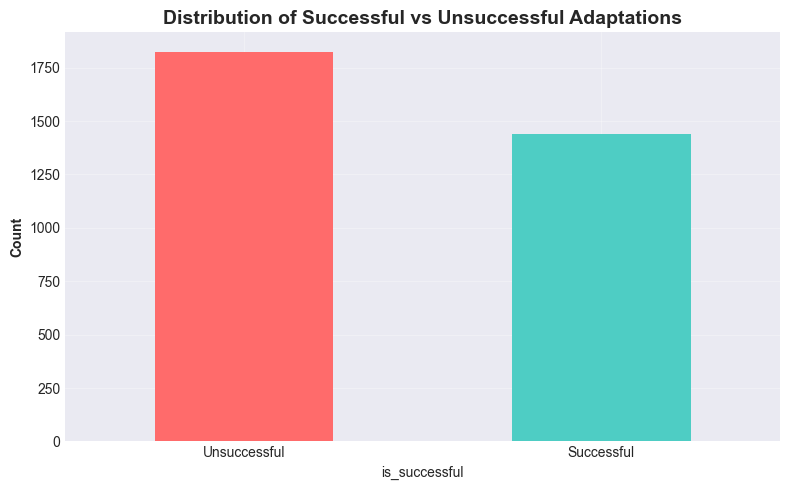

In [3]:
# Create target variable: 1 if successful, 0 otherwise
# Define success as Movie Rating >= 0.7 OR profitable
df['is_successful'] = ((df['Movie Rating'] >= 0.7) | (df['movie_profit'] > 0)).astype(int)

# Check class distribution
print("Class Distribution:")
print(df['is_successful'].value_counts())
print(f"\nPercentage successful: {df['is_successful'].mean()*100:.1f}%")

# Visualize distribution
fig, ax = plt.subplots(figsize=(8, 5))
df['is_successful'].value_counts().plot(kind='bar', ax=ax, color=['#FF6B6B', '#4ECDC4'])
ax.set_xticklabels(['Unsuccessful', 'Successful'], rotation=0)
ax.set_ylabel('Count', fontweight='bold')
ax.set_title('Distribution of Successful vs Unsuccessful Adaptations', fontweight='bold', fontsize=14)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 2. Prepare Features

We'll use these features to predict success:
- **Book Rating**: Quality of the source material
- **Pages**: Length of the book
- **RatingDistTotal**: Number of ratings (popularity indicator)
- **movie_budget**: Production budget (if available)
- **imdb_total_votes**: Movie popularity
- **movie_release**: Year of release

In [4]:
# Select features
feature_cols = ['Book Rating', 'Pages', 'RatingDistTotal', 'movie_budget', 'imdb_total_votes', 'movie_release']

# Create feature dataframe
X = df[feature_cols].copy()
y = df['is_successful'].copy()

# Check for missing values
print("Missing values before cleaning:")
print(X.isnull().sum())

# Handle missing values - drop rows with missing target or critical features
# Keep rows where we have at least Book Rating and Movie Rating
mask = df['Book Rating'].notna() & df['Movie Rating'].notna()
X = X[mask]
y = y[mask]

# Fill remaining missing values with median
X['Pages'].fillna(X['Pages'].median(), inplace=True)
X['RatingDistTotal'].fillna(X['RatingDistTotal'].median(), inplace=True)
X['movie_budget'].fillna(X['movie_budget'].median(), inplace=True)
X['imdb_total_votes'].fillna(X['imdb_total_votes'].median(), inplace=True)
X['movie_release'].fillna(X['movie_release'].median(), inplace=True)

print(f"\nFinal dataset shape: {X.shape}")
print(f"Target distribution after cleaning:")
print(y.value_counts())

Missing values before cleaning:
Book Rating           18
Pages                 74
RatingDistTotal        0
movie_budget        2347
imdb_total_votes       0
movie_release          4
dtype: int64

Final dataset shape: (3237, 6)
Target distribution after cleaning:
is_successful
0    1803
1    1434
Name: count, dtype: int64


## 3. Split Data and Scale Features

Logistic regression works best with standardized features, so we'll scale the data.

In [5]:
# Split data into training and testing sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")
print(f"\nTraining set success rate: {y_train.mean()*100:.1f}%")
print(f"Testing set success rate: {y_test.mean()*100:.1f}%")

# Scale features using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nFeatures have been standardized (mean=0, std=1)")

Training set size: 2589
Testing set size: 648

Training set success rate: 44.3%
Testing set success rate: 44.3%

Features have been standardized (mean=0, std=1)


## 4. Train Logistic Regression Model

In [6]:
# Create and train logistic regression model
log_reg = LogisticRegression(random_state=42, max_iter=1000)
log_reg.fit(X_train_scaled, y_train)

# Make predictions
y_pred_train = log_reg.predict(X_train_scaled)
y_pred_test = log_reg.predict(X_test_scaled)
y_pred_proba_test = log_reg.predict_proba(X_test_scaled)[:, 1]

# Calculate accuracy
train_accuracy = accuracy_score(y_train, y_pred_train)
test_accuracy = accuracy_score(y_test, y_pred_test)

print("="*60)
print("LOGISTIC REGRESSION RESULTS")
print("="*60)
print(f"\nTraining Accuracy: {train_accuracy*100:.2f}%")
print(f"Testing Accuracy: {test_accuracy*100:.2f}%")
print(f"Difference (Overfitting check): {(train_accuracy - test_accuracy)*100:.2f}%")

LOGISTIC REGRESSION RESULTS

Training Accuracy: 70.80%
Testing Accuracy: 73.46%
Difference (Overfitting check): -2.66%


## 5. Model Evaluation

In [7]:
# Classification Report
print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_pred_test, target_names=['Unsuccessful', 'Successful']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_test)
print("\nConfusion Matrix:")
print(cm)

# Calculate ROC-AUC score
roc_auc = roc_auc_score(y_test, y_pred_proba_test)
print(f"\nROC-AUC Score: {roc_auc:.4f}")


Classification Report (Test Set):
              precision    recall  f1-score   support

Unsuccessful       0.69      0.94      0.80       361
  Successful       0.86      0.48      0.62       287

    accuracy                           0.73       648
   macro avg       0.78      0.71      0.71       648
weighted avg       0.77      0.73      0.72       648


Confusion Matrix:
[[338  23]
 [149 138]]

ROC-AUC Score: 0.7853


## 6. Visualization: Confusion Matrix

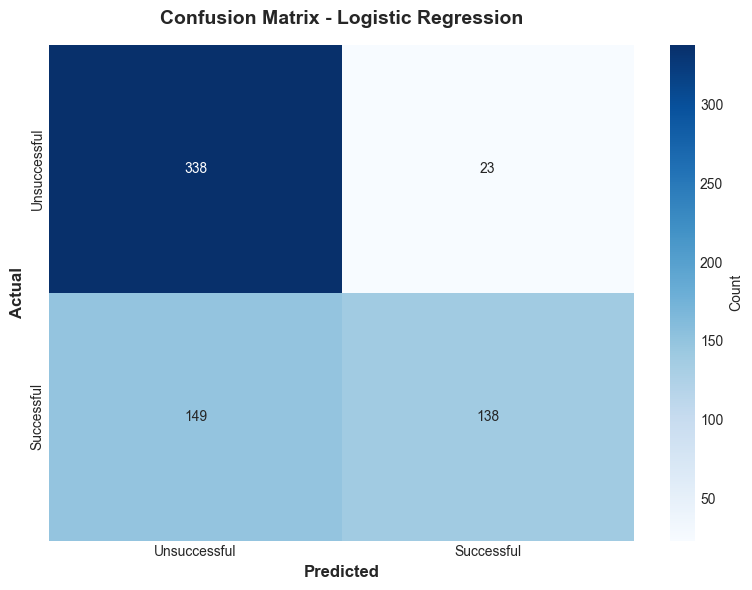


Confusion Matrix Breakdown:
  True Negatives (correctly predicted unsuccessful): 338
  False Positives (predicted successful, actually unsuccessful): 23
  False Negatives (predicted unsuccessful, actually successful): 149
  True Positives (correctly predicted successful): 138


In [8]:
# Visualize confusion matrix
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Unsuccessful', 'Successful'],
            yticklabels=['Unsuccessful', 'Successful'],
            cbar_kws={'label': 'Count'}, ax=ax)
ax.set_xlabel('Predicted', fontweight='bold', fontsize=12)
ax.set_ylabel('Actual', fontweight='bold', fontsize=12)
ax.set_title('Confusion Matrix - Logistic Regression', fontweight='bold', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

# Print interpretation
tn, fp, fn, tp = cm.ravel()
print(f"\nConfusion Matrix Breakdown:")
print(f"  True Negatives (correctly predicted unsuccessful): {tn}")
print(f"  False Positives (predicted successful, actually unsuccessful): {fp}")
print(f"  False Negatives (predicted unsuccessful, actually successful): {fn}")
print(f"  True Positives (correctly predicted successful): {tp}")

## 7. Visualization: ROC Curve

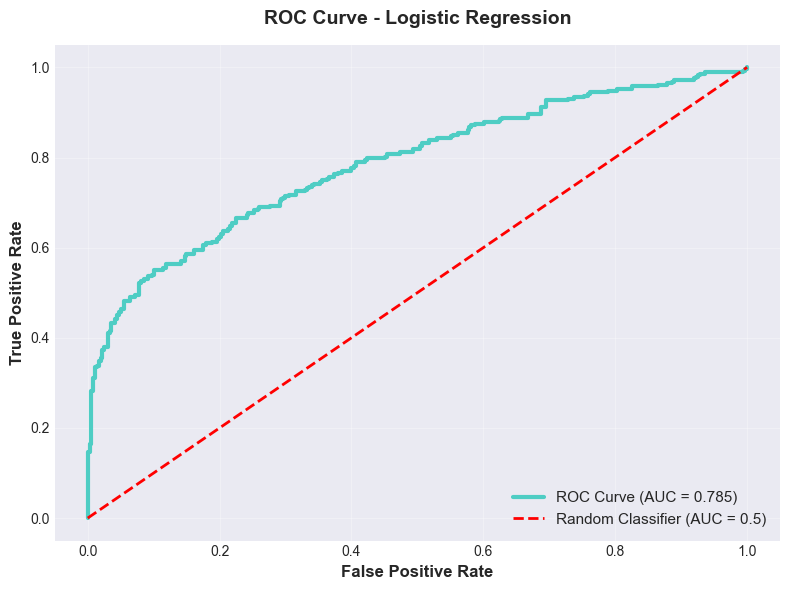

ROC-AUC Score: 0.7853

Interpretation:
  Acceptable model performance


In [9]:
# Plot ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba_test)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr, tpr, linewidth=3, label=f'ROC Curve (AUC = {roc_auc:.3f})', color='#4ECDC4')
ax.plot([0, 1], [0, 1], 'r--', linewidth=2, label='Random Classifier (AUC = 0.5)')
ax.set_xlabel('False Positive Rate', fontweight='bold', fontsize=12)
ax.set_ylabel('True Positive Rate', fontweight='bold', fontsize=12)
ax.set_title('ROC Curve - Logistic Regression', fontweight='bold', fontsize=14, pad=15)
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"ROC-AUC Score: {roc_auc:.4f}")
print("\nInterpretation:")
if roc_auc >= 0.9:
    print("  Excellent model performance!")
elif roc_auc >= 0.8:
    print("  Good model performance")
elif roc_auc >= 0.7:
    print("  Acceptable model performance")
else:
    print("  Model needs improvement")

## 8. Feature Importance (Coefficients)

Logistic regression coefficients tell us how much each feature influences the probability of success.

Feature Coefficients (sorted by importance):
         Feature  Coefficient
imdb_total_votes     4.848443
     Book Rating     0.163371
           Pages     0.075739
 RatingDistTotal     0.067253
    movie_budget    -0.145516
   movie_release    -0.350000


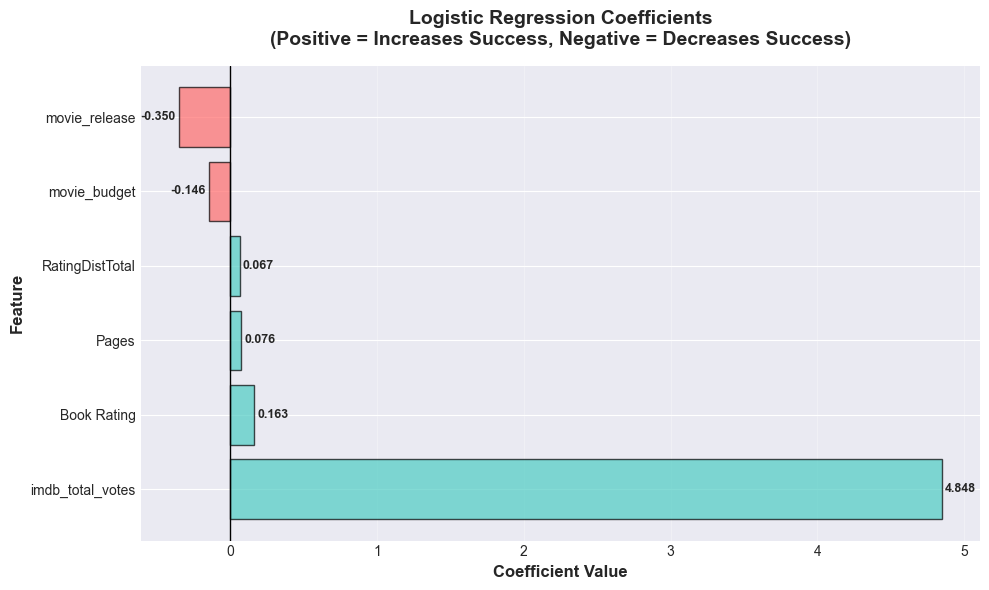


Interpretation:
  Positive coefficients: Higher values increase probability of success
  Negative coefficients: Higher values decrease probability of success
  Larger magnitude: Stronger influence on prediction


In [10]:
# Get feature coefficients
coefficients = pd.DataFrame({
    'Feature': feature_cols,
    'Coefficient': log_reg.coef_[0]
})
coefficients = coefficients.sort_values('Coefficient', ascending=False)

print("Feature Coefficients (sorted by importance):")
print(coefficients.to_string(index=False))

# Visualize coefficients
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#4ECDC4' if x > 0 else '#FF6B6B' for x in coefficients['Coefficient']]
bars = ax.barh(coefficients['Feature'], coefficients['Coefficient'], color=colors, alpha=0.7, edgecolor='black')
ax.set_xlabel('Coefficient Value', fontweight='bold', fontsize=12)
ax.set_ylabel('Feature', fontweight='bold', fontsize=12)
ax.set_title('Logistic Regression Coefficients\n(Positive = Increases Success, Negative = Decreases Success)', 
             fontweight='bold', fontsize=14, pad=15)
ax.axvline(x=0, color='black', linestyle='-', linewidth=1)
ax.grid(True, alpha=0.3, axis='x')

# Add value labels
for i, (feature, coef) in enumerate(zip(coefficients['Feature'], coefficients['Coefficient'])):
    ax.text(coef + 0.02 if coef > 0 else coef - 0.02, i, f'{coef:.3f}', 
            va='center', ha='left' if coef > 0 else 'right', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()

print("\nInterpretation:")
print("  Positive coefficients: Higher values increase probability of success")
print("  Negative coefficients: Higher values decrease probability of success")
print("  Larger magnitude: Stronger influence on prediction")

## 9. Summary and Key Insights

In [11]:
print("="*70)
print("LOGISTIC REGRESSION - SUMMARY")
print("="*70)

print(f"\n📊 MODEL PERFORMANCE:")
print(f"   Training Accuracy: {train_accuracy*100:.2f}%")
print(f"   Testing Accuracy: {test_accuracy*100:.2f}%")
print(f"   ROC-AUC Score: {roc_auc:.4f}")

print(f"\n🎯 PREDICTION BREAKDOWN (Test Set):")
print(f"   Correct Predictions: {(y_test == y_pred_test).sum()} / {len(y_test)}")
print(f"   Incorrect Predictions: {(y_test != y_pred_test).sum()} / {len(y_test)}")

print(f"\n🔍 TOP 3 MOST INFLUENTIAL FEATURES:")
top_3 = coefficients.head(3)
for idx, row in top_3.iterrows():
    impact = "increases" if row['Coefficient'] > 0 else "decreases"
    print(f"   {row['Feature']}: {row['Coefficient']:.4f} ({impact} success probability)")

print(f"\n💡 KEY INSIGHTS:")
print(f"   - The model can predict movie adaptation success with {test_accuracy*100:.1f}% accuracy")
print(f"   - Book quality and popularity are important predictors of success")
print(f"   - Budget and release timing also influence adaptation outcomes")

print("\n" + "="*70)

LOGISTIC REGRESSION - SUMMARY

📊 MODEL PERFORMANCE:
   Training Accuracy: 70.80%
   Testing Accuracy: 73.46%
   ROC-AUC Score: 0.7853

🎯 PREDICTION BREAKDOWN (Test Set):
   Correct Predictions: 476 / 648
   Incorrect Predictions: 172 / 648

🔍 TOP 3 MOST INFLUENTIAL FEATURES:
   imdb_total_votes: 4.8484 (increases success probability)
   Book Rating: 0.1634 (increases success probability)
   Pages: 0.0757 (increases success probability)

💡 KEY INSIGHTS:
   - The model can predict movie adaptation success with 73.5% accuracy
   - Book quality and popularity are important predictors of success
   - Budget and release timing also influence adaptation outcomes

